In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmedzayed30","key":"9377e753b6e995271b8c07341d7beda2"}'}

In [2]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews --unzip

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
100% 25.7M/25.7M [00:00<00:00, 164MB/s] 



In [3]:
import pandas as pd

df = pd.read_csv('/content/IMDB Dataset.csv')
print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

print(df['sentiment'].value_counts())
df[['clean_review', 'sentiment']].head()

sentiment
1    25000
0    25000
Name: count, dtype: int64


,clean_review,sentiment
0,one of the other reviewers has mentioned that ...,1
1,a wonderful little production the filming tech...,1
2,i thought this was a wonderful way to spend ti...,1
3,basically theres a family where a little boy j...,0
4,petter matteis love in the time of money is a ...,1


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Accuracy: 89.55%
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



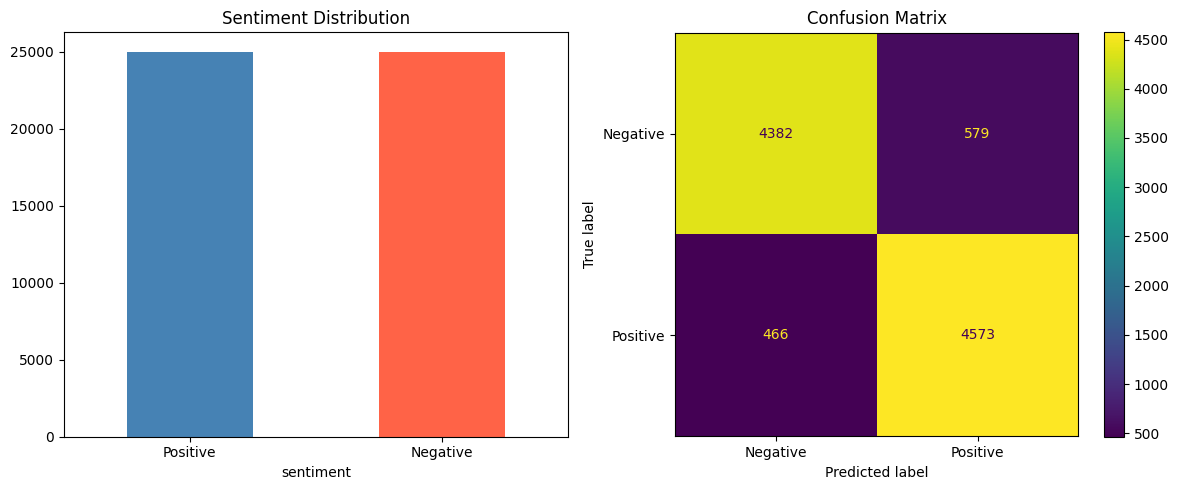

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sentiment Distribution
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
                                    color=['steelblue', 'tomato'])
axes[0].set_title('Sentiment Distribution')
axes[0].set_xticklabels(['Positive', 'Negative'], rotation=0)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(ax=axes[1])
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150)
plt.show()

In [7]:
import gradio as gr

def predict_sentiment(review):
    clean = clean_text(review)
    vectorized = tfidf.transform([clean])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]

    if prediction == 1:
        return f"✅ Positive ({probability[1]:.0%} confidence)"
    else:
        return f"❌ Negative ({probability[0]:.0%} confidence)"

gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=5, placeholder="Write your movie review here..."),
    outputs=gr.Textbox(label="Sentiment"),
    title="🎬 Movie Review Sentiment Analyzer",
    description="Paste any movie review and the model will predict if it's positive or negative (Accuracy: 89.55%)"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b2138c7623d607d80f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
